In [7]:

%load_ext autoreload
%autoreload 2
import h5py
import numpy as np
import config
import autoencoder
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(array([ 96., 125., 174., 219., 178., 154., 101.,  97.,  74.,  48.,  40.,
         44.,  33.,  30.,  20.,  28.,  20.,  28.,  21.,  17.,  18.,  18.,
         20.,  22.,   9.,  15.,  13.,  11.,  19.,  15.,  14.,   7.,   4.,
          6.,   7.,   7.,   5.,   5.,   3.,   4.,   5.,   2.,   2.,   1.,
          5.,   0.,   2.,   0.,   1.,   2.,   3.,   3.,   4.,   1.,   1.,
          2.,   2.,   0.,   2.,   0.,   1.,   2.,   1.,   0.,   0.,   0.,
          2.,   1.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([0.        , 0.02763999, 0.05527997, 0.08291996, 0.11055994,
        0.13819993, 0.16583991, 0.1934799 , 0.22111989, 0.24875987,
        0.27639986, 0.30403984, 0.33167983, 0.35931981, 0.3869598 ,
        0.41459979, 0.44223977, 0.46987976, 0.49751974, 0.52515973,
        0.55279971, 0.5804397 , 0.60807969, 0.

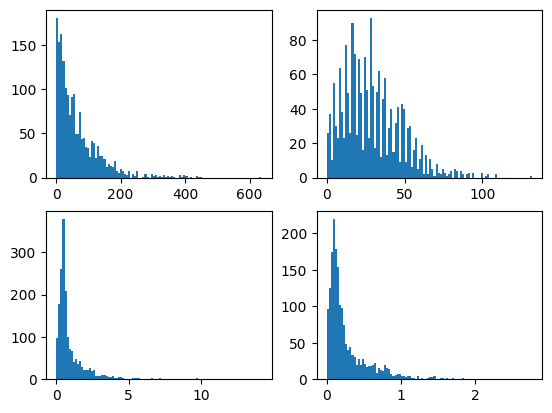

In [8]:

groups = ['ps20nm']

area = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='area', groups=groups)
circum = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='circum', groups=groups)
disloc = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='disloc', groups=groups)
eccen = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='eccen', groups=groups)
flags = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='flags', groups=groups)
xs = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='xs', groups=groups)
ys = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='ys', groups=groups)

thumbnails = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', groups=groups)
proc = autoencoder.process_thumbnails(thumbnails)

fig, ax = plt.subplots(2,2)
ax[0,0].hist(area, bins=100)
#ax[0,0].vlines(500, ymin=0, ymax=6000, color='red')
ax[0,1].hist(circum, bins=100)
#ax[0,1].vlines(100, ymin=0, ymax=100, color='red')
ax[1,0].hist(disloc, bins=100)
#ax[1,0].vlines(5, ymin=0, ymax=1000, color='red')
ax[1,1].hist(eccen, bins=100)
#ax[1,1].vlines(3.5, ymin=0, ymax=1000, color='red')
      

In [11]:
with h5py.File(f'{config.DATA_DIR}/coords.h5','r') as f:
    pca_coords = f['/pca_coords'][:]
    umap_coords = f['/umap_coords'][:]

plt.figure()
plt.scatter(pca_coords[:,0], pca_coords[:,2], c=area)

IndexError: index 2 is out of bounds for axis 1 with size 2

<Figure size 640x480 with 0 Axes>

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Output()

Output()

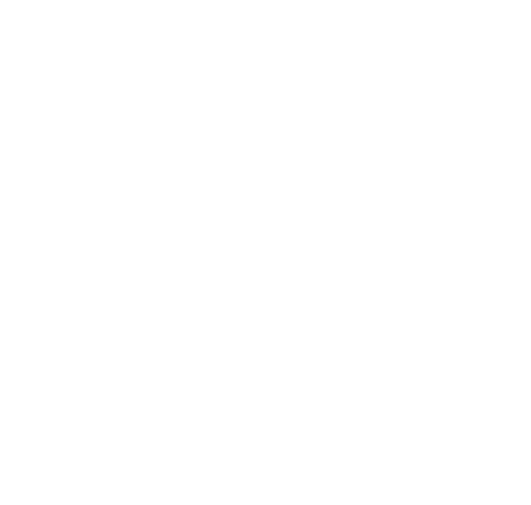

In [13]:

%load_ext autoreload
%autoreload 2

# 1. Import the class from your newly made script
from boxselector import BoxSelector
# 2. Instantiate the class by passing in your data variables
selector = BoxSelector(pca_coords, flags)
# 3. Call .show() to render everything beautifully in your cell
selector.show()

In [7]:
%load_ext autoreload
%autoreload 2
    
import h5py
import matplotlib.pyplot as plt
import numpy as np
from autoencoder import process_thumbnails
from ipywidgets import interact




with h5py.File('../data/thumbnails.h5','r') as f:
    print(f['/'].keys())
    print(f['/ps20nm'].keys())
    thumb = f['/ps20nm/thumbnails'][...]
    flags = f['/ps20nm/flags'][...]

processed = process_thumbnails(thumb, thresh=0.1).squeeze()
thumb.shape

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
<KeysViewHDF5 ['ferri', 'groel', 'ps20nm', 'ps30nm', 'ps40nm', 'ps50nm']>
<KeysViewHDF5 ['area', 'circum', 'disloc', 'eccen', 'flags', 'is', 'max', 'mean', 'median', 'min', 'thumbnails', 'xs', 'ys']>


(1818, 60, 60)

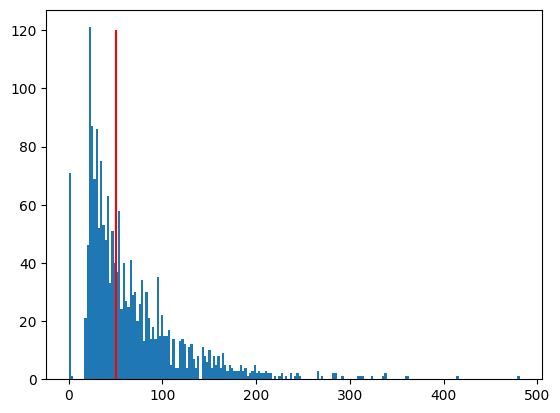

In [11]:
_= plt.hist(processed.sum(axis=(1,2)), bins=200)
plt.vlines(np.median(processed.sum(axis=(1,2))), ymin=0, ymax=120, color='red')

In [3]:
#fig, axs = plt.subplots(4,4)
#for ax in axs.flatten():
#    ax.imshow(processed[np.random.randint(0, ferri.shape[0]),:,:])


In [4]:
@interact(slice_index=(0, processed.shape[0] - 1))
def plot_slice(slice_index=0):
    fig, ax = plt.subplots(1,2, figsize=(6, 6))
    ax[0].imshow(thumb[slice_index, :, :])
    ax[1].imshow(processed[slice_index, :, :])
    plt.title(processed[slice_index, :, :].sum())
    plt.axis("off")
    plt.show()

interactive(children=(IntSlider(value=0, description='slice_index', max=1817), Output()), _dom_classes=('widge…